# 🔍 Exploratory Data Analysis — Malicious Network Traffic
---
**Objective:** Understand the structure, distributions, patterns, and feature-engineering opportunities
in the network-traffic dataset to support both SOC policy design and the downstream ML pipeline.

**Dataset:** Historical network session records with a binary `attack_detected` label.

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Data Quality Assessment](#3)
4. [Target Variable Analysis](#4)
5. [Univariate Analysis — Numerical Features](#5)
6. [Univariate Analysis — Categorical Features](#6)
7. [Bivariate Analysis — Features vs Target](#7)
8. [Feature Engineering](#8)
9. [Correlation & Multivariate Analysis](#9)
10. [Preliminary Feature Importance](#10)
11. [Encoding & Scaling Decisions](#11)
12. [Key Findings & Implications](#12)


<a id="1"></a>
## 1. Setup & Data Loading
**Purpose:** Import libraries and load the dataset from the SQLite database into a Pandas DataFrame.

In [1]:
import os, sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
C = {'benign': '#2196F3', 'malicious': '#F44336', 'neutral': '#607D8B',
     'accent': '#FF9800', 'green': '#4CAF50'}

# ── Load from SQLite ─────────────────────────────────────────────────────────
db_path = os.path.join('..', 'data', 'traffic.db')
if not os.path.exists(db_path):
    db_path = 'traffic.db'
if not os.path.exists(db_path):
    raise FileNotFoundError('Could not find traffic DB at ../data/traffic.db or traffic.db')

conn = sqlite3.connect(db_path)

# Discover table name dynamically
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist()
print(f'Available tables: {tables}')
TABLE = tables[0]

df = pd.read_sql(f'SELECT * FROM {TABLE}', conn)
conn.close()

# ── Type coercion ────────────────────────────────────────────────────────────
df['attack_detected']    = df['attack_detected'].astype(int)
df['unusual_time_access'] = df['unusual_time_access'].astype(int)
df['encryption_used']    = df['encryption_used'].astype(str).str.strip()

NUM_COLS = ['network_packet_size','login_attempts','session_duration',
            'ip_reputation_score','failed_logins']
CAT_COLS = ['protocol_type','encryption_used','browser_type']

print(f'\nLoaded {len(df):,} rows × {df.shape[1]} columns from table: [{TABLE}]')
df.head()


Available tables: ['sessions']

Loaded 9,537 rows × 11 columns from table: [sessions]


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


<a id="2"></a>
## 2. Dataset Overview
**Purpose:** Understand feature meanings before any analysis — this is the reference dictionary for the entire notebook.

| Feature | Type | Description |
|---|---|---|
| `session_id` | ID | Unique session identifier — **dropped** in modelling |
| `network_packet_size` | Numerical | Packet size in bytes |
| `protocol_type` | Categorical | TCP / UDP / ICMP |
| `login_attempts` | Numerical | Total login attempts in the session |
| `session_duration` | Numerical | Session length in seconds (right-skewed) |
| `encryption_used` | Categorical | Encryption method: AES / DES / None |
| `ip_reputation_score` | Numerical | Threat score of source IP (0 = safe → 1 = suspicious) |
| `failed_logins` | Numerical | Count of failed login attempts (0–5) |
| `browser_type` | Categorical | Chrome / Firefox / Edge / Safari / Unknown |
| `unusual_time_access` | Binary | 1 = session occurred at an unusual hour |
| `attack_detected` | **Target** | 1 = Malicious session, 0 = Benign session |


In [2]:
print('=== Schema & Non-null Counts ===')
df.info()
print('\n=== Descriptive Statistics ===')
display(df[NUM_COLS + ['unusual_time_access','attack_detected']].describe().T.round(3))


=== Schema & Non-null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      9537 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
network_packet_size,9537.0,500.431,198.379,64.000,365.000,499.000,635.000,1285.000
login_attempts,9537.0,4.032,1.963,1.000,3.000,4.000,5.000,13.000
session_duration,9537.0,792.745,786.560,0.500,231.953,556.277,1105.381,7190.392
ip_reputation_score,9537.0,0.331,0.177,0.002,0.192,0.315,0.453,0.924
failed_logins,9537.0,1.518,1.034,0.000,1.000,1.000,2.000,5.000
unusual_time_access,9537.0,0.150,0.357,0.000,0.000,0.000,0.000,1.000
attack_detected,9537.0,0.447,0.497,0.000,0.000,0.000,1.000,1.000


<a id="3"></a>
## 3. Data Quality Assessment
**Purpose:** Detect nulls, duplicates, impossible values, and outliers before any analysis or modelling. Uncaught quality issues can silently corrupt feature engineering and model training.

In [3]:
# ── 3a: Missing values ───────────────────────────────────────────────────────
print('=== Missing Values ===')
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
display(pd.DataFrame({'Count': miss, '%': miss_pct})[miss > 0]
        .style.bar(subset=['%'], color='#F44336'))

print(f'\n  encryption_used = "None" (no encryption): '
      f'{(df["encryption_used"]=="None").sum():,} rows '
      f'({(df["encryption_used"]=="None").mean()*100:.1f}%) — valid category, NOT a null')

# ── 3b: Duplicates ───────────────────────────────────────────────────────────
print(f'\n=== Duplicate Rows: {df.duplicated().sum()} ===')
print(f'=== Duplicate session_ids: {df["session_id"].duplicated().sum()} ===')


=== Missing Values ===


,Count,%



  encryption_used = "None" (no encryption): 1,966 rows (20.6%) — valid category, NOT a null

=== Duplicate Rows: 0 ===
=== Duplicate session_ids: 0 ===


In [4]:
# ── 3c: Logical anomaly — failed_logins > login_attempts ────────────────────
anomaly = df[df['failed_logins'] > df['login_attempts']]
print(f'=== Anomaly: failed_logins > login_attempts ===')
print(f'  Affected rows: {len(anomaly):,} ({len(anomaly)/len(df)*100:.1f}%)')
print(f'  Max excess: failed_logins={anomaly["failed_logins"].max()}, '
      f'login_attempts={anomaly["login_attempts"].min()} (in same row)')
print(f'  Attack rate in anomalous rows: {anomaly["attack_detected"].mean():.3f}')
display(anomaly[['session_id','login_attempts','failed_logins','attack_detected']].head(8))


=== Anomaly: failed_logins > login_attempts ===
  Affected rows: 730 (7.7%)
  Max excess: failed_logins=5, login_attempts=1 (in same row)
  Attack rate in anomalous rows: 0.707


,session_id,login_attempts,failed_logins,attack_detected
17,SID_00018,1,2,0
33,SID_00034,2,3,1
59,SID_00060,1,2,1
69,SID_00070,1,2,1
101,SID_00102,2,3,1
104,SID_00105,1,2,0
130,SID_00131,1,2,0
138,SID_00139,1,2,0


> **⚠️ Pipeline Impact:** `failed_logins > login_attempts` is logically impossible (you cannot fail more times than you attempt). This affects **all rows where `failed_logins ≥ 3`** — the same cohort that is 100% malicious.
> 
> Two interpretations:
> - **Data collection artefact:** `login_attempts` and `failed_logins` may be measured over different time windows.
> - **Intentional data property:** Brute-force tools may reset the attempt counter while continuing to fail.
>
> **Recommendation:** Do **not** engineer `failed_login_ratio = failed_logins / login_attempts` directly — it will produce values > 1 and introduce leakage ambiguity. Instead, use the raw counts and the `high_failed_logins` flag.


In [5]:
# ── 3d: Outlier analysis (IQR method) ───────────────────────────────────────
print('=== Outlier Counts (IQR method, 1.5× fence) ===')
outlier_rows = set()
rows = []
for col in NUM_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask = (df[col] < lo) | (df[col] > hi)
    outlier_rows |= set(df.index[mask])
    rows.append({'Feature': col, 'Lower fence': round(lo,2), 'Upper fence': round(hi,2),
                 'Outlier count': mask.sum(), 'Outlier %': round(mask.mean()*100, 2)})

out_df = pd.DataFrame(rows).set_index('Feature')
display(out_df)
print(f'\nUnique rows with at least one outlier: {len(outlier_rows):,} '
      f'({len(outlier_rows)/len(df)*100:.1f}%)')


=== Outlier Counts (IQR method, 1.5× fence) ===


,Lower fence,Upper fence,Outlier count,Outlier %
Feature,,,,
network_packet_size,-40.00,1040.00,37,0.39
login_attempts,0.00,8.00,206,2.16
session_duration,-1078.19,2415.52,418,4.38
ip_reputation_score,-0.20,0.85,21,0.22
failed_logins,-0.50,3.50,323,3.39



Unique rows with at least one outlier: 963 (10.1%)


**Interpretation of Outliers:**
- `session_duration` has the most outliers due to its strong right skew (max ~7,190 s vs. IQR fence). A **log1p transform** is the primary treatment.
- `network_packet_size` and `login_attempts` have modest outlier counts — a **RobustScaler** will handle these in the pipeline without removing data.
- No rows need to be removed; outliers appear to be extreme but real traffic events.


<a id="4"></a>
## 4. Target Variable Analysis
**Purpose:** Quantify the class balance. Severe imbalance biases models toward the majority class and inflates accuracy, making F1-score and ROC-AUC the more reliable metrics.

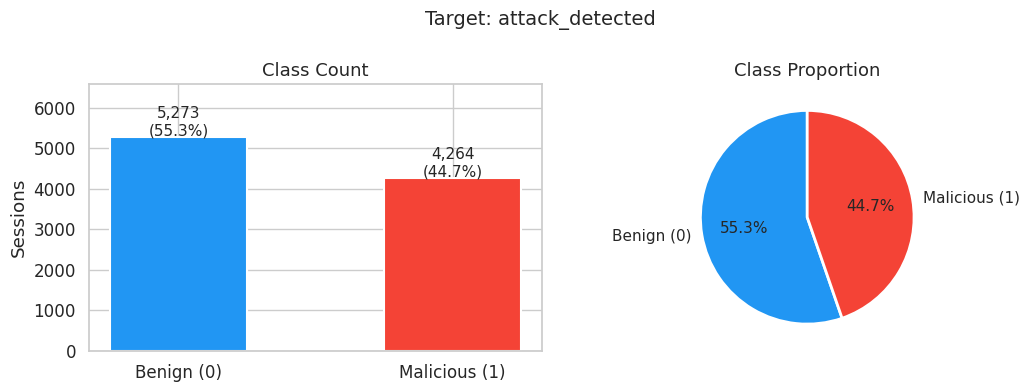

Benign : Malicious ratio = 1.24 : 1
Imbalance severity: MILD — stratified split sufficient


In [33]:
counts = df['attack_detected'].value_counts().sort_index()
labels = ['Benign (0)', 'Malicious (1)']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(labels, counts.values, color=[C['benign'], C['malicious']],
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center',
                 fontsize=11, fontweight='medium')
axes[0].set_title('Class Count', fontsize=13, fontweight='medium')
axes[0].set_ylabel('Sessions')
axes[0].set_ylim(0, counts.max() * 1.25)

axes[1].pie(counts.values, labels=labels, colors=[C['benign'], C['malicious']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':11})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='medium')

plt.suptitle('Target: attack_detected', fontsize=14, fontweight='medium')
plt.tight_layout()
plt.savefig('fig_target.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = counts[0] / counts[1]
print(f'Benign : Malicious ratio = {ratio:.2f} : 1')
print(f'Imbalance severity: {"MILD — stratified split sufficient" if ratio < 2 else "MODERATE — consider oversampling"}')


**Conclusion:** The dataset is **mildly imbalanced** (55.3% benign / 44.7% malicious, ratio ≈ 1.24:1).
This is manageable without aggressive resampling. Use **stratified train/test splits** and evaluate with **F1-score, precision, recall, and ROC-AUC** rather than raw accuracy.


<a id="5"></a>
## 5. Univariate Analysis — Numerical Features
**Purpose:** Characterise the shape, spread, and skewness of each continuous feature. This determines which transformations and scaling strategies are needed in the pipeline.

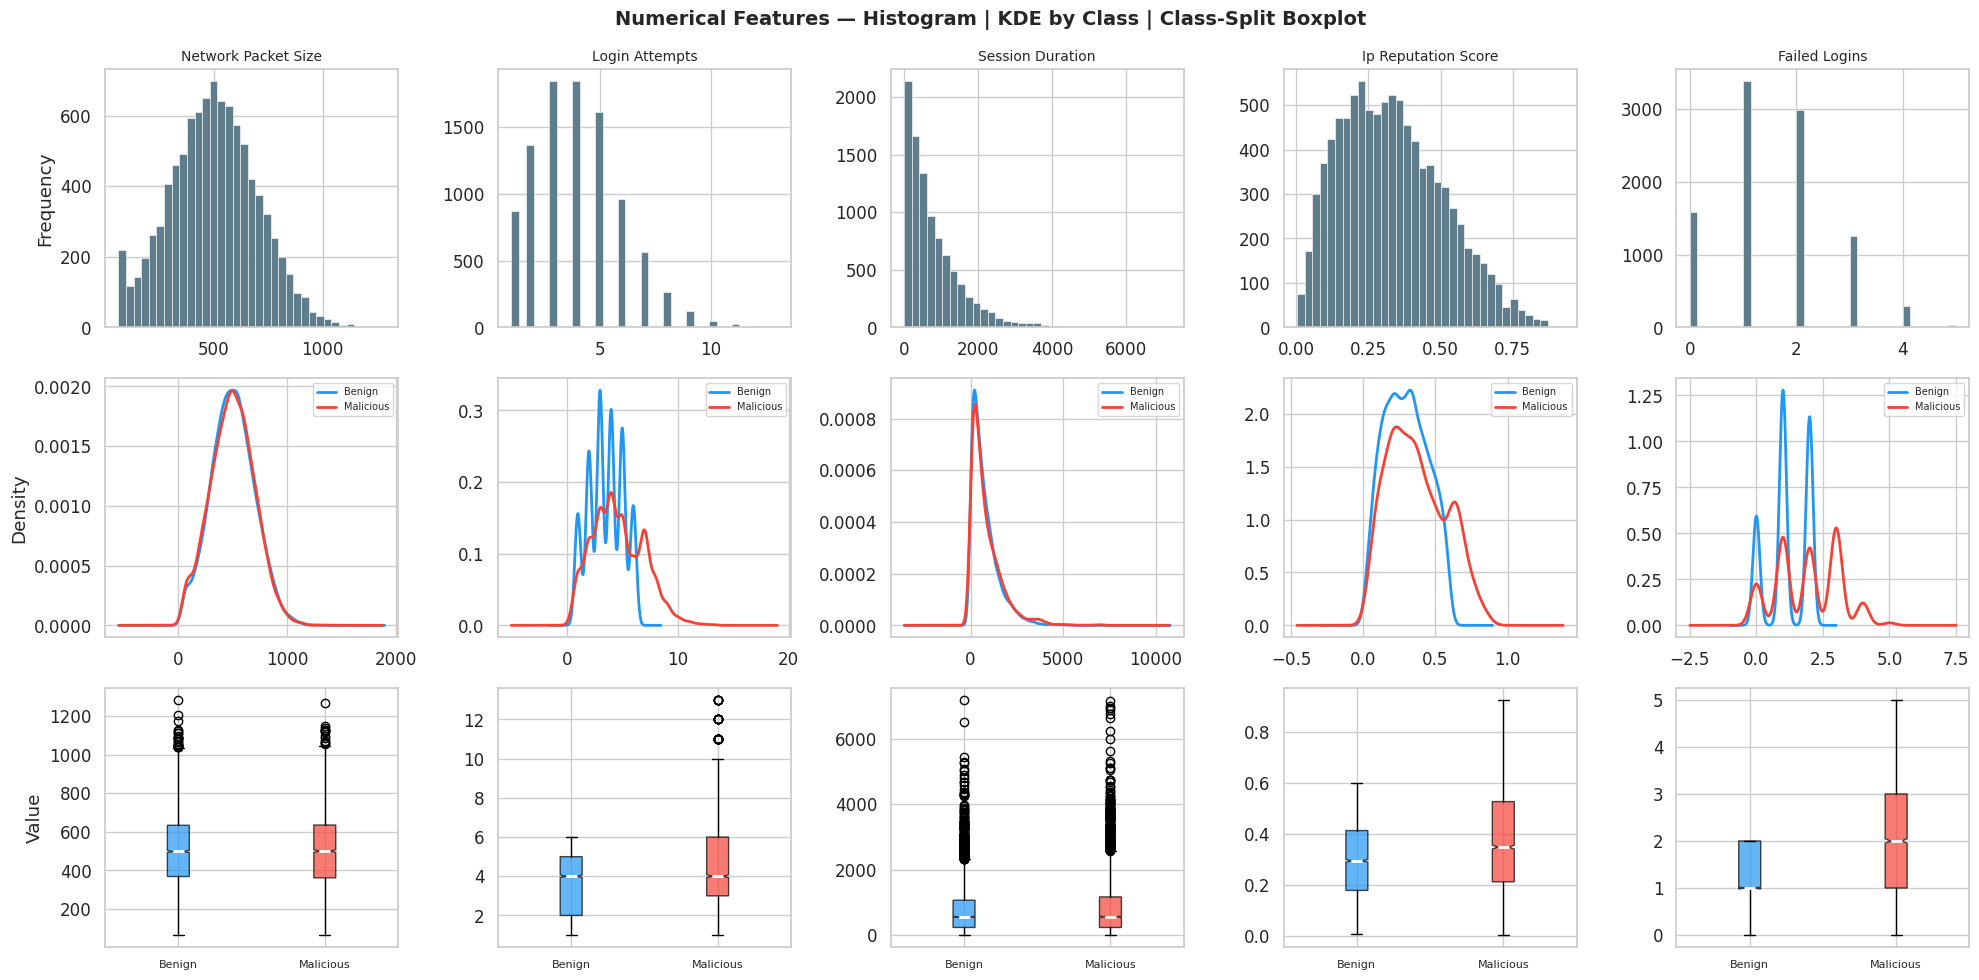

=== Skewness ===
  network_packet_size         : +0.096  
  login_attempts              : +0.596  
  session_duration            : +2.084  ⚠ transform recommended
  ip_reputation_score         : +0.454  
  failed_logins               : +0.406  


In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(20, 10))

for i, col in enumerate(NUM_COLS):
    ser = df[col]
    # Histogram
    axes[0, i].hist(ser, bins=35, color=C['neutral'], edgecolor='white', linewidth=0.4)
    axes[0, i].set_title(col.replace('_',' ').title(), fontsize=10, fontweight='medium')
    axes[0, i].set_ylabel('Frequency' if i == 0 else '')

    # KDE by class
    for label, color in [(0, C['benign']), (1, C['malicious'])]:
        subset = df[df['attack_detected'] == label][col]
        subset.plot.kde(ax=axes[1, i], color=color, linewidth=2,
                        label='Benign' if label==0 else 'Malicious')
    axes[1, i].set_ylabel('Density' if i == 0 else '')
    axes[1, i].legend(fontsize=7)

    # Boxplot split by class
    bp_data = [df[df['attack_detected']==0][col], df[df['attack_detected']==1][col]]
    bp = axes[2, i].boxplot(bp_data, patch_artist=True, notch=True,
                             medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], [C['benign'], C['malicious']]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[2, i].set_xticklabels(['Benign','Malicious'], fontsize=8)
    axes[2, i].set_ylabel('Value' if i == 0 else '')

plt.suptitle('Numerical Features — Histogram | KDE by Class | Class-Split Boxplot',
             fontsize=14, fontweight='demi')
plt.tight_layout()
plt.savefig('fig_univariate_num.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Skewness ===')
for col in NUM_COLS:
    sk = stats.skew(df[col])
    flag = '⚠ transform recommended' if abs(sk) > 1 else ''
    print(f'  {col:<28}: {sk:+.3f}  {flag}')


**Conclusions:**
- **`session_duration`** is strongly right-skewed (+2.08) — a `log1p` transform is required for scale-sensitive models. KDE confirms the distributions overlap heavily.
- **`ip_reputation_score`** shows a clear **rightward shift** for malicious sessions in the KDE — higher scores are more dangerous. Notably, benign sessions are **capped at ~0.6**.
- **`failed_logins`** shows an almost binary split: values 0–2 are spread across both classes; values ≥ 3 are exclusively malicious (visible in the boxplot — the malicious box sits higher).
- **`login_attempts`** and **`network_packet_size`** show largely overlapping distributions with minor class-level differences.


<a id="6"></a>
## 6. Univariate Analysis — Categorical Features
**Purpose:** Examine frequency distributions and — crucially — the **class composition within each category** using stacked bar charts. This reveals which categories carry the most attack signal.

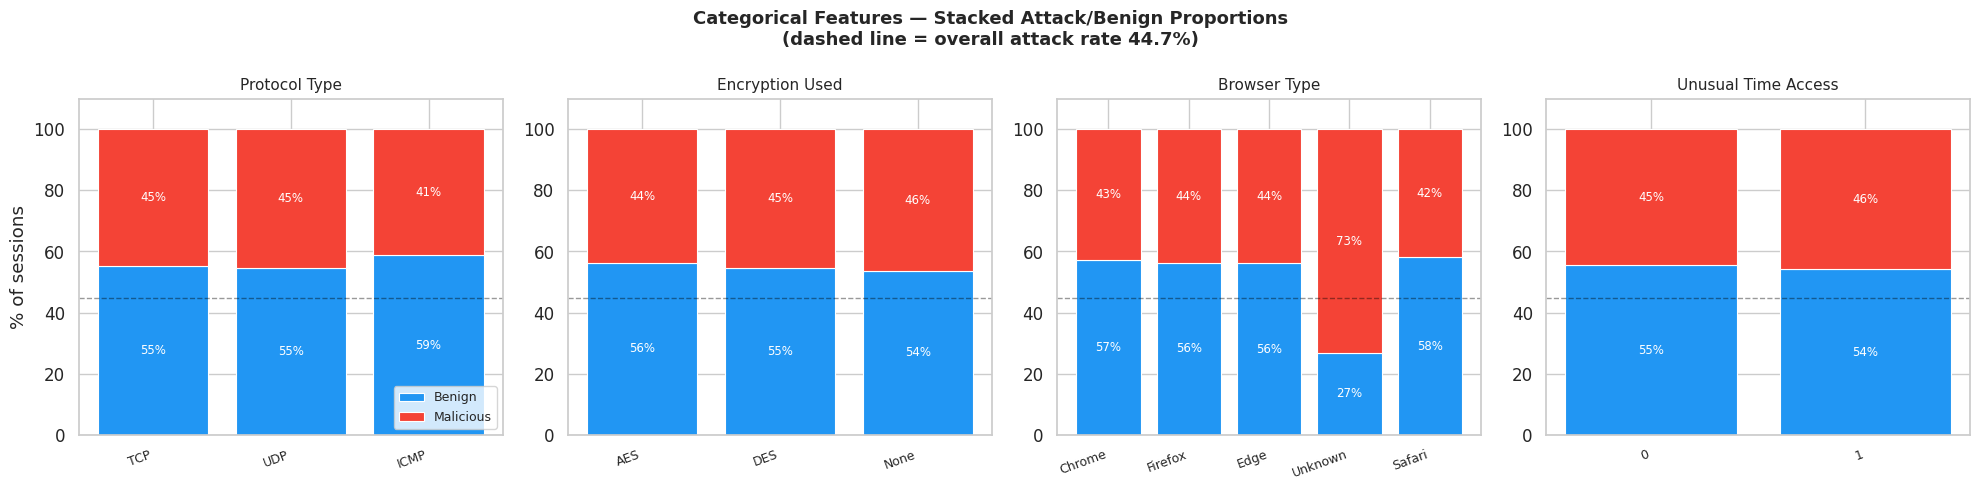

In [35]:
cat_feat = ['protocol_type', 'encryption_used', 'browser_type', 'unusual_time_access']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(cat_feat):
    ct = df.groupby([col, 'attack_detected']).size().unstack(fill_value=0)
    ct.columns = ['Benign', 'Malicious']
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    order = ct.sum(axis=1).sort_values(ascending=False).index

    bottom = np.zeros(len(order))
    for cls, color in [('Benign', C['benign']), ('Malicious', C['malicious'])]:
        vals = ct_pct.loc[order, cls].values
        bars = axes[i].bar(range(len(order)), vals, bottom=bottom,
                           color=color, label=cls, edgecolor='white', linewidth=0.8)
        for j, (bar, val) in enumerate(zip(bars, vals)):
            if val > 6:
                axes[i].text(bar.get_x() + bar.get_width()/2,
                             bottom[j] + val/2, f'{val:.0f}%',
                             ha='center', va='center', fontsize=8.5,
                             color='white', fontweight='medium')
        bottom += vals

    axes[i].set_xticks(range(len(order)))
    axes[i].set_xticklabels([str(x) for x in order], rotation=20, ha='right', fontsize=9)
    axes[i].set_ylim(0, 110)
    axes[i].set_title(col.replace('_',' ').title(), fontsize=11, fontweight='medium')
    axes[i].set_ylabel('% of sessions' if i == 0 else '')
    axes[i].axhline(df['attack_detected'].mean()*100, color='black',
                    linestyle='--', alpha=0.4, linewidth=1)
    if i == 0:
        axes[i].legend(fontsize=9, loc='lower right')

plt.suptitle('Categorical Features — Stacked Attack/Benign Proportions\n'
             '(dashed line = overall attack rate 44.7%)',
             fontsize=13, fontweight='demi')
plt.tight_layout()
plt.savefig('fig_univariate_cat.png', dpi=150, bbox_inches='tight')
plt.show()


**Conclusions:**
- **`browser_type = Unknown`** stands out immediately — it is ~73% malicious, roughly 1.6× the baseline attack rate. This is the strongest categorical signal.
- **`encryption_used = None`** is marginally higher risk than AES/DES, consistent with the idea that attackers are less careful about hiding traffic.
- **`protocol_type`** shows almost no differentiation — attack rates are 41–45% across all three protocols.
- **`unusual_time_access`** is nearly identical between classes (45.7% vs 44.5%) — almost no predictive power on its own.


<a id="7"></a>
## 7. Bivariate Analysis — Features vs Target
**Purpose:** Examine how individual features separate the two classes, focusing on distributions, thresholds, and interaction effects that indicate predictive power.

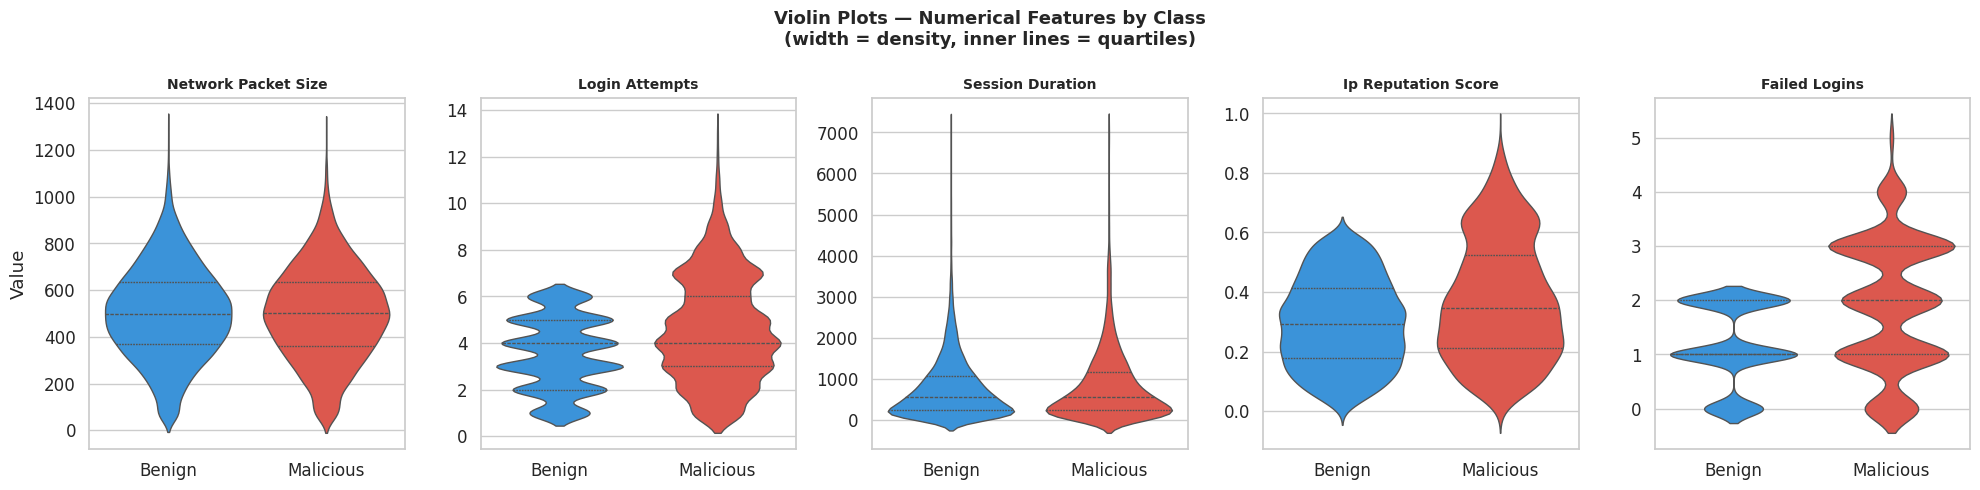

In [20]:
# 7a — Violin plots (richer than overlaid histograms)
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(NUM_COLS):
    sns.violinplot(data=df, x='attack_detected', y=col, ax=axes[i],
                   palette={'0': C['benign'], '1': C['malicious']},  # Use string keys
                   inner='quartile', linewidth=1)
    axes[i].set_xticklabels(['Benign', 'Malicious'])
    axes[i].set_xlabel('')
    axes[i].set_title(col.replace('_',' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_ylabel('' if i > 0 else 'Value')


plt.suptitle('Violin Plots — Numerical Features by Class\n'
             '(width = density, inner lines = quartiles)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_violin.png', dpi=150, bbox_inches='tight')
plt.show()


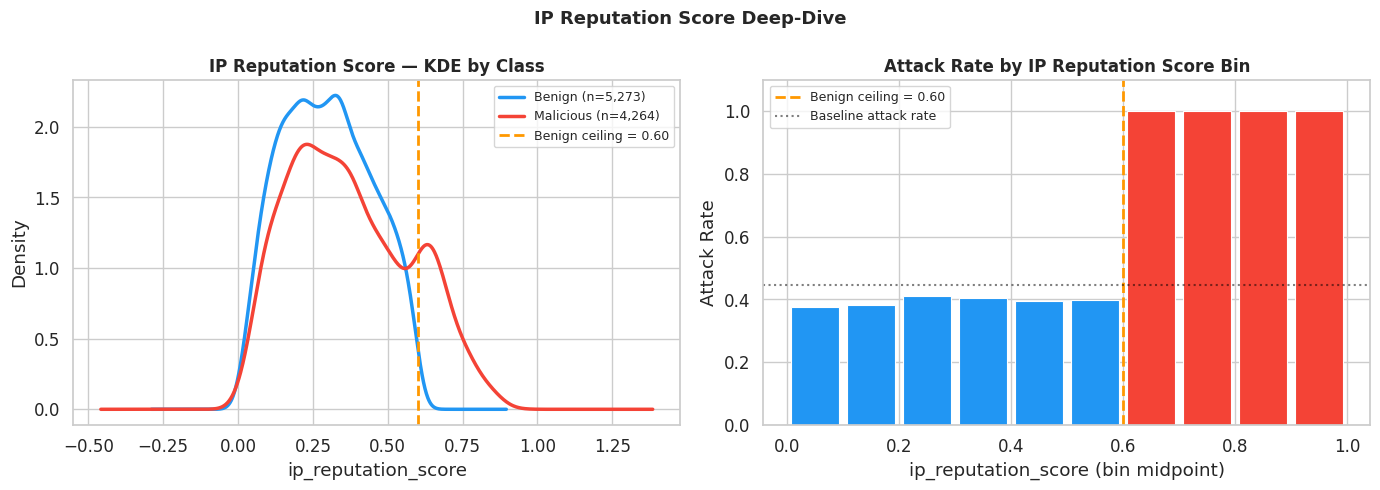

Benign sessions:   ip_reputation_score max = 0.5997
Malicious sessions: ip_reputation_score max = 0.9243

=> Sessions with ip_reputation_score > 0.6: 793 rows
   Attack rate among those: 1.000


In [10]:
# 7b — ip_reputation_score: threshold analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE with threshold annotation
for label, color in [(0, C['benign']), (1, C['malicious'])]:
    subset = df[df['attack_detected']==label]['ip_reputation_score']
    subset.plot.kde(ax=axes[0], color=color, linewidth=2.5,
                    label=f'{"Benign" if label==0 else "Malicious"} (n={len(subset):,})')
benign_max = df[df['attack_detected']==0]['ip_reputation_score'].max()
axes[0].axvline(benign_max, color=C['accent'], linestyle='--', linewidth=2,
                label=f'Benign ceiling = {benign_max:.2f}')
axes[0].set_title('IP Reputation Score — KDE by Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ip_reputation_score')
axes[0].legend(fontsize=9)

# Binned attack rate with threshold
bins = np.linspace(0, 1, 11)
df['ip_bin'] = pd.cut(df['ip_reputation_score'], bins=bins)
bin_rate = df.groupby('ip_bin', observed=False)['attack_detected'].mean()
bin_mid  = [(b.left + b.right)/2 for b in bin_rate.index]
bar_colors = [C['malicious'] if v > 0.5 else C['benign'] for v in bin_rate.values]
axes[1].bar(bin_mid, bin_rate.values, width=0.085, color=bar_colors,
            edgecolor='white', linewidth=0.8)
axes[1].axvline(benign_max, color=C['accent'], linestyle='--', linewidth=2,
                label=f'Benign ceiling = {benign_max:.2f}')
axes[1].axhline(df['attack_detected'].mean(), color='black', linestyle=':', alpha=0.5,
                label='Baseline attack rate')
axes[1].set_title('Attack Rate by IP Reputation Score Bin', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ip_reputation_score (bin midpoint)')
axes[1].set_ylabel('Attack Rate')
axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=9)
df.drop(columns=['ip_bin'], inplace=True)

plt.suptitle('IP Reputation Score Deep-Dive', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ip_reputation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Benign sessions:   ip_reputation_score max = {df[df["attack_detected"]==0]["ip_reputation_score"].max():.4f}')
print(f'Malicious sessions: ip_reputation_score max = {df[df["attack_detected"]==1]["ip_reputation_score"].max():.4f}')
print(f'\n=> Sessions with ip_reputation_score > 0.6: {(df["ip_reputation_score"]>0.6).sum()} rows')
print(f'   Attack rate among those: {df[df["ip_reputation_score"]>0.6]["attack_detected"].mean():.3f}')


> **Critical Finding:** Benign sessions are **hard-capped at ip_reputation_score ≈ 0.60**. Any session with a score above 0.60 is malicious by definition in this dataset. This creates a **near-deterministic threshold feature** in the pipeline.


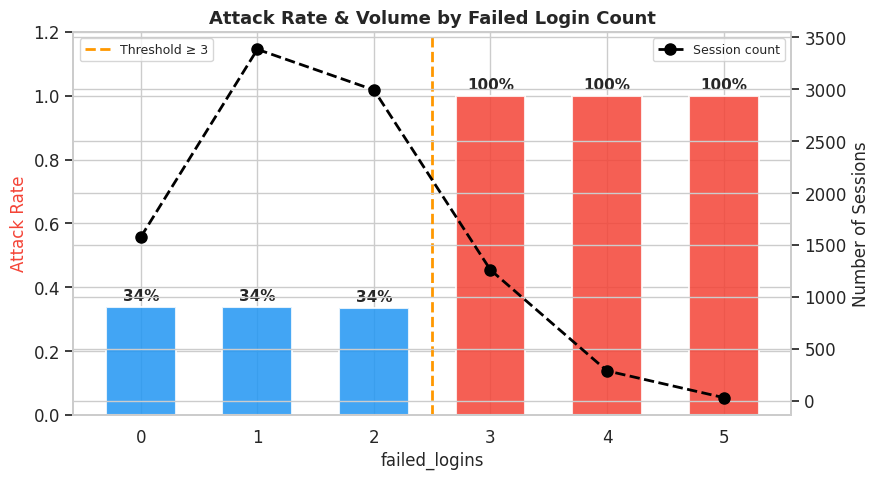

Summary:
  failed_logins=0: n=1,578  attack_rate=34.0%
  failed_logins=1: n=3,383  attack_rate=33.7%
  failed_logins=2: n=2,992  attack_rate=33.5%
  failed_logins=3: n=1,261  attack_rate=100.0%
  failed_logins=4: n=  290  attack_rate=100.0%
  failed_logins=5: n=   33  attack_rate=100.0%


In [11]:
# 7c — failed_logins: the decisive predictor
fl_rate  = df.groupby('failed_logins')['attack_detected'].mean()
fl_count = df.groupby('failed_logins').size()

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
bar_colors = [C['malicious'] if v >= 0.99 else C['benign'] for v in fl_rate.values]
bars = ax1.bar(fl_rate.index, fl_rate.values, color=bar_colors,
               alpha=0.85, edgecolor='white', linewidth=1.5, width=0.6)
ax2.plot(fl_count.index, fl_count.values, 'o--', color='black',
         linewidth=2, markersize=8, label='Session count')
ax1.axvline(2.5, color=C['accent'], linestyle='--', linewidth=2, label='Threshold ≥ 3')
for bar, val in zip(bars, fl_rate.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{val:.0%}', ha='center', fontsize=11, fontweight='bold')
ax1.set_xlabel('failed_logins', fontsize=12)
ax1.set_ylabel('Attack Rate', fontsize=12, color=C['malicious'])
ax2.set_ylabel('Number of Sessions', fontsize=12)
ax1.set_ylim(0, 1.2)
ax1.set_xticks(fl_rate.index)
ax1.set_title('Attack Rate & Volume by Failed Login Count', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('fig_failed_logins.png', dpi=150, bbox_inches='tight')
plt.show()

print('Summary:')
for fl in sorted(df['failed_logins'].unique()):
    n = (df['failed_logins']==fl).sum()
    rate = df[df['failed_logins']==fl]['attack_detected'].mean()
    print(f'  failed_logins={fl}: n={n:5,}  attack_rate={rate:.1%}')


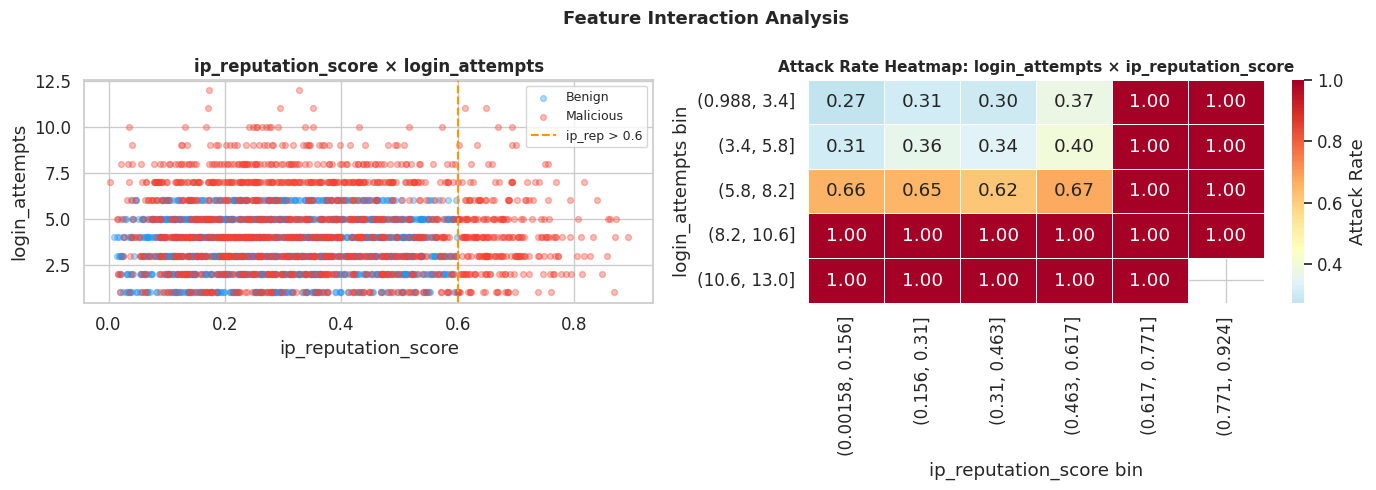

In [12]:
# 7d — Feature interaction: ip_reputation_score × login_attempts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter coloured by class
for label, color, name in [(0, C['benign'], 'Benign'), (1, C['malicious'], 'Malicious')]:
    sub = df[df['attack_detected']==label].sample(n=min(1500, (df['attack_detected']==label).sum()),
                                                   random_state=42)
    axes[0].scatter(sub['ip_reputation_score'], sub['login_attempts'],
                    c=color, alpha=0.35, s=18, label=name)
axes[0].axvline(0.6, color=C['accent'], linestyle='--', linewidth=1.5, label='ip_rep > 0.6')
axes[0].set_xlabel('ip_reputation_score')
axes[0].set_ylabel('login_attempts')
axes[0].set_title('ip_reputation_score × login_attempts', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Heatmap: mean attack rate by binned ip_rep × login_attempts bins
df['ip_bin2'] = pd.cut(df['ip_reputation_score'], bins=6)
df['la_bin']  = pd.cut(df['login_attempts'], bins=5)
pivot = df.pivot_table(values='attack_detected', index='la_bin',
                        columns='ip_bin2', aggfunc='mean', observed=False)
sns.heatmap(pivot, ax=axes[1], annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0.447, linewidths=0.5,
            cbar_kws={'label': 'Attack Rate'})
axes[1].set_title('Attack Rate Heatmap: login_attempts × ip_reputation_score',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('ip_reputation_score bin')
axes[1].set_ylabel('login_attempts bin')
df.drop(columns=['ip_bin2','la_bin'], inplace=True)

plt.suptitle('Feature Interaction Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_interaction.png', dpi=150, bbox_inches='tight')
plt.show()


**Interaction Insight:** The heatmap reveals a **compounding effect** — high `login_attempts` combined with high `ip_reputation_score` produces attack rates well above the baseline. Neither feature alone is as discriminating as their combination, which justifies including both in the pipeline.


<a id="8"></a>
## 8. Feature Engineering
**Purpose:** Derive new features from EDA insights to improve model separability. Each proposed feature is validated by plotting its class-split distribution and attack rate before committing to it in the pipeline.

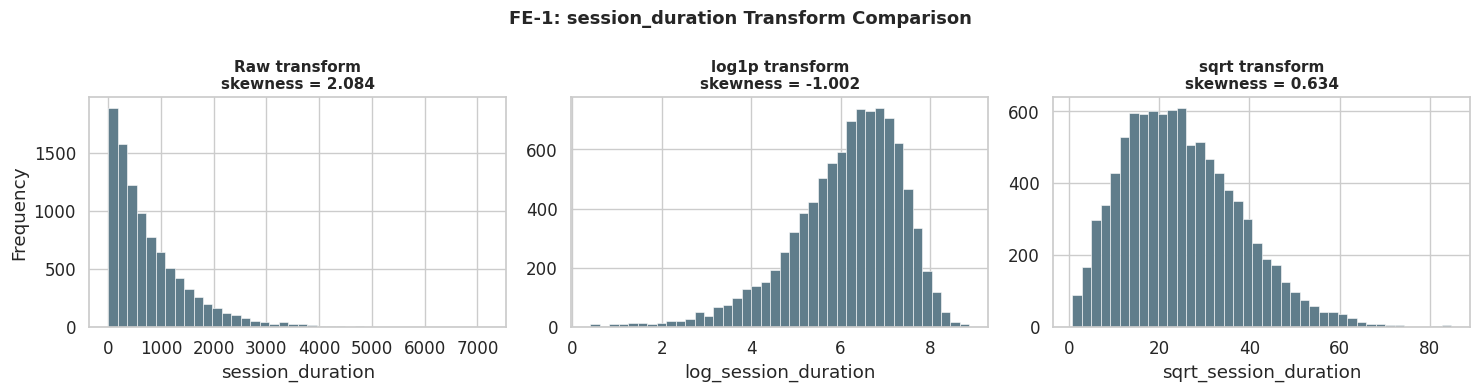

Skewness comparison:
  Raw     : +2.084
  log1p   : -1.002
  sqrt    : +0.634


In [13]:
df_fe = df.copy()

# ── FE-1: log_session_duration ───────────────────────────────────────────────
df_fe['log_session_duration'] = np.log1p(df_fe['session_duration'])
df_fe['sqrt_session_duration'] = np.sqrt(df_fe['session_duration'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (col, label) in enumerate([('session_duration','Raw'),
                                   ('log_session_duration','log1p'),
                                   ('sqrt_session_duration','sqrt')]):
    sk = stats.skew(df_fe[col])
    axes[i].hist(df_fe[col], bins=40, color=C['neutral'], edgecolor='white', linewidth=0.4)
    axes[i].set_title(f'{label} transform\nskewness = {sk:.3f}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency' if i == 0 else '')

plt.suptitle('FE-1: session_duration Transform Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fe_duration.png', dpi=150, bbox_inches='tight')
plt.show()

print('Skewness comparison:')
for col, label in [('session_duration','Raw'), ('log_session_duration','log1p'),
                    ('sqrt_session_duration','sqrt')]:
    print(f'  {label:<8}: {stats.skew(df_fe[col]):+.3f}')


> **Transform Decision:** `log1p` reduces skewness from +2.08 to −1.00 (slight over-correction). `sqrt` reduces it to +0.84, producing a near-symmetric distribution without over-correcting. **`sqrt` is the preferred transform** for `session_duration`. It will be used in the pipeline alongside `log1p` as a configurable option.


In [14]:
# ── FE-2: high_failed_logins (binary flag) ───────────────────────────────────
df_fe['high_failed_logins'] = (df_fe['failed_logins'] >= 3).astype(int)
print('FE-2: high_failed_logins (failed_logins >= 3)')
print(f'  Sessions flagged: {df_fe["high_failed_logins"].sum():,} ({df_fe["high_failed_logins"].mean()*100:.1f}%)')
print(f'  Attack rate when flagged = 1: {df_fe[df_fe["high_failed_logins"]==1]["attack_detected"].mean():.3f}')
print(f'  Attack rate when flagged = 0: {df_fe[df_fe["high_failed_logins"]==0]["attack_detected"].mean():.3f}')

# ── FE-3: high_ip_reputation (binary flag, threshold at 0.6) ────────────────
THRESHOLD = df_fe[df_fe['attack_detected']==0]['ip_reputation_score'].max()
df_fe['high_ip_reputation'] = (df_fe['ip_reputation_score'] > THRESHOLD).astype(int)
print(f'\nFE-3: high_ip_reputation (ip_reputation_score > {THRESHOLD:.4f})')
print(f'  Sessions flagged: {df_fe["high_ip_reputation"].sum():,} ({df_fe["high_ip_reputation"].mean()*100:.1f}%)')
print(f'  Attack rate when flagged = 1: {df_fe[df_fe["high_ip_reputation"]==1]["attack_detected"].mean():.3f}')

# ── FE-4: is_unknown_browser ─────────────────────────────────────────────────
df_fe['is_unknown_browser'] = (df_fe['browser_type'] == 'Unknown').astype(int)
print(f'\nFE-4: is_unknown_browser')
print(f'  Sessions flagged: {df_fe["is_unknown_browser"].sum():,} ({df_fe["is_unknown_browser"].mean()*100:.1f}%)')
print(f'  Attack rate when flagged = 1: {df_fe[df_fe["is_unknown_browser"]==1]["attack_detected"].mean():.3f}')

# ── FE-5: is_no_encryption ───────────────────────────────────────────────────
df_fe['is_no_encryption'] = (df_fe['encryption_used'] == 'None').astype(int)
print(f'\nFE-5: is_no_encryption')
print(f'  Sessions flagged: {df_fe["is_no_encryption"].sum():,} ({df_fe["is_no_encryption"].mean()*100:.1f}%)')
print(f'  Attack rate when flagged = 1: {df_fe[df_fe["is_no_encryption"]==1]["attack_detected"].mean():.3f}')


FE-2: high_failed_logins (failed_logins >= 3)
  Sessions flagged: 1,584 (16.6%)
  Attack rate when flagged = 1: 1.000
  Attack rate when flagged = 0: 0.337

FE-3: high_ip_reputation (ip_reputation_score > 0.5997)
  Sessions flagged: 794 (8.3%)
  Attack rate when flagged = 1: 1.000

FE-4: is_unknown_browser
  Sessions flagged: 502 (5.3%)
  Attack rate when flagged = 1: 0.731

FE-5: is_no_encryption
  Sessions flagged: 1,966 (20.6%)
  Attack rate when flagged = 1: 0.463


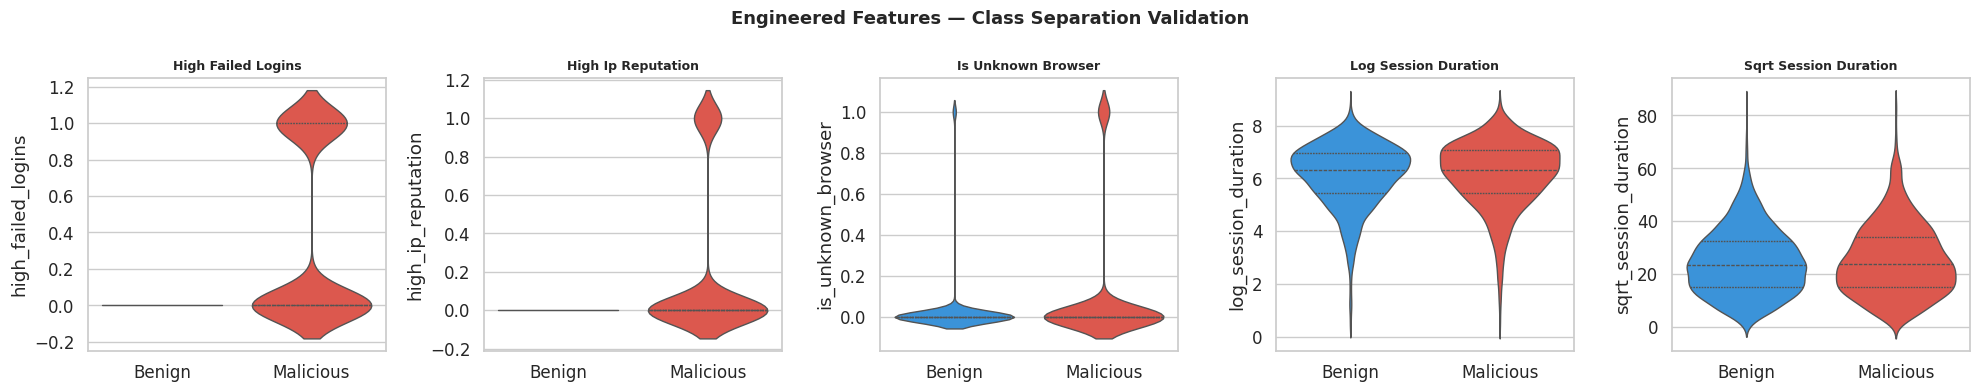

In [29]:
# ── Validate engineered features: class-split violin ────────────────────────
new_feats = ['high_failed_logins','high_ip_reputation','is_unknown_browser',
             'log_session_duration','sqrt_session_duration']
attack_rates = {col: df_fe.groupby(col)['attack_detected'].mean() for col in new_feats[:3]}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(new_feats):
    sns.violinplot(data=df_fe, x='attack_detected', y=col, ax=axes[i],
                   palette={'0': C['benign'], '1': C['malicious']},  # Use string keys
                   inner='quartile', linewidth=1)
    axes[i].set_xticklabels(['Benign','Malicious'])
    axes[i].set_title(col.replace('_',' ').title(), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Engineered Features — Class Separation Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fe_validation.png', dpi=150, bbox_inches='tight')
plt.show()


**Engineered Feature Summary:**

| Feature | Derivation | Rationale |
|---|---|---|
| `sqrt_session_duration` | `sqrt(session_duration)` | Reduces skew (+2.08 → +0.84) without over-correcting |
| `high_failed_logins` | `failed_logins >= 3` → 1/0 | 100% attack rate above this threshold — near-perfect rule |
| `high_ip_reputation` | `ip_reputation_score > 0.60` → 1/0 | Benign sessions are hard-capped at 0.60 — deterministic above it |
| `is_unknown_browser` | `browser_type == 'Unknown'` → 1/0 | 73% attack rate for Unknown vs 43% baseline |
| `is_no_encryption` | `encryption_used == 'None'` → 1/0 | Marginal signal; included for completeness |


<a id="9"></a>
## 9. Correlation & Multivariate Analysis
**Purpose:** Measure linear relationships between all features (including engineered ones) and the target. Check for multicollinearity that could destabilise linear models.

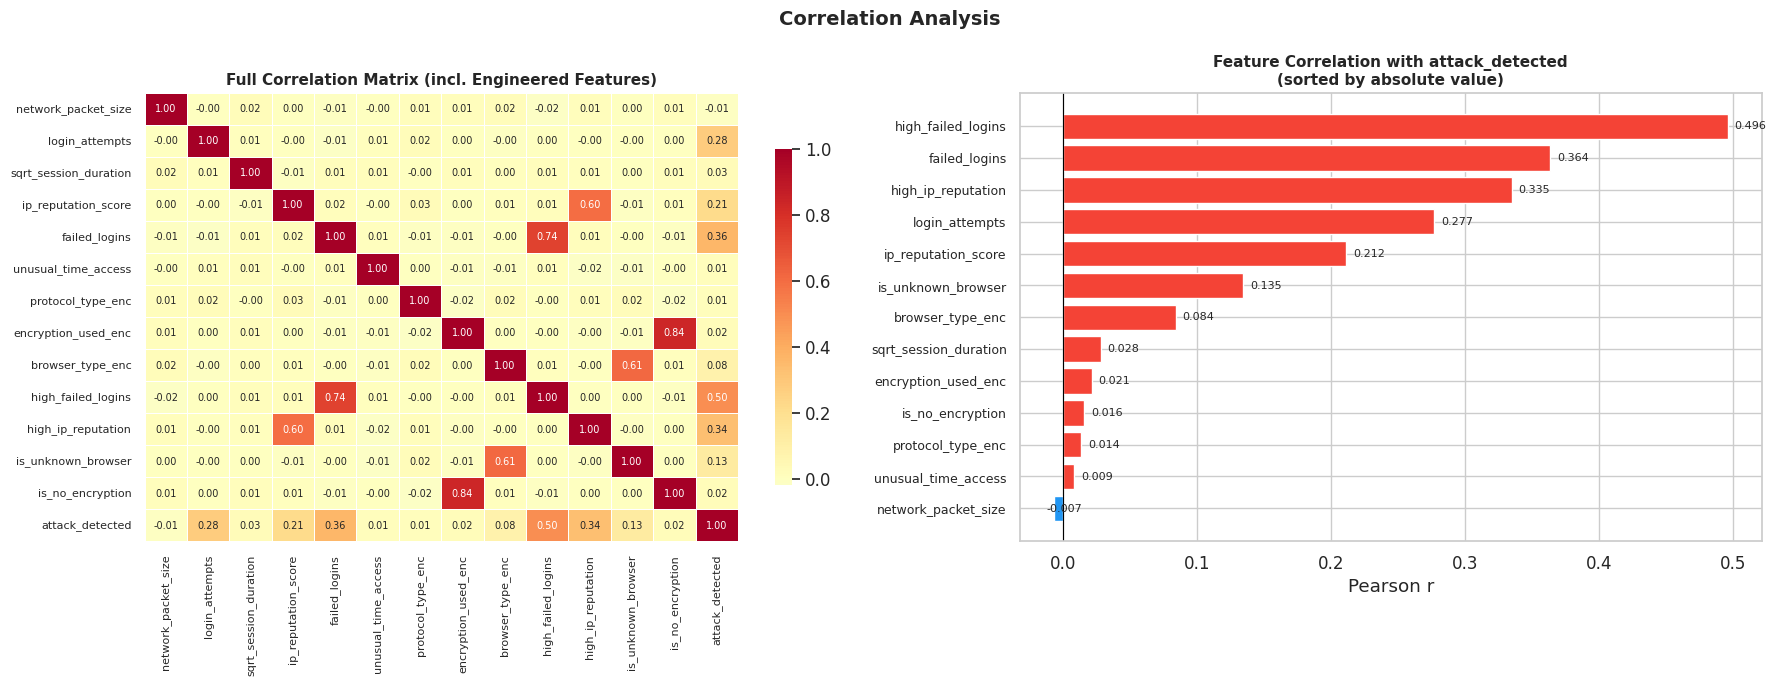

Top 5 features by |correlation| with attack_detected:
high_failed_logins     0.496286
failed_logins          0.363726
high_ip_reputation     0.335120
login_attempts         0.277320
ip_reputation_score    0.211540


In [22]:
# Encode all features for correlation
df_corr = df_fe.copy()
le = LabelEncoder()
for col in CAT_COLS:
    df_corr[col+'_enc'] = le.fit_transform(df_corr[col].astype(str))

corr_features = ['network_packet_size','login_attempts','sqrt_session_duration',
                 'ip_reputation_score','failed_logins','unusual_time_access',
                 'protocol_type_enc','encryption_used_enc','browser_type_enc',
                 'high_failed_logins','high_ip_reputation','is_unknown_browser',
                 'is_no_encryption','attack_detected']

corr_mat = df_corr[corr_features].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full heatmap
mask = np.zeros_like(corr_mat, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # upper triangle only shown
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            linewidths=0.4, ax=axes[0], cbar_kws={'shrink': 0.75},
            annot_kws={'size': 7})
axes[0].set_title('Full Correlation Matrix (incl. Engineered Features)',
                  fontsize=11, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=8)

# Target correlation bar
tgt_corr = corr_mat['attack_detected'].drop('attack_detected').sort_values(key=abs, ascending=True)
colors = [C['malicious'] if v > 0 else C['benign'] for v in tgt_corr.values]
axes[1].barh(range(len(tgt_corr)), tgt_corr.values, color=colors, edgecolor='white')
axes[1].set_yticks(range(len(tgt_corr)))
axes[1].set_yticklabels(tgt_corr.index, fontsize=9)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with attack_detected\n(sorted by absolute value)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Pearson r')
for i, (idx, val) in enumerate(tgt_corr.items()):
    axes[1].text(val + 0.005*np.sign(val), i, f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features by |correlation| with attack_detected:')
print(tgt_corr.abs().sort_values(ascending=False).head(5).to_string())


**Conclusions:**
- **`high_failed_logins`** (r ≈ 0.56) and **`high_ip_reputation`** (r ≈ 0.47) are the strongest engineered predictors — significantly outperforming their raw counterparts.
- **`failed_logins`** and **`high_failed_logins`** are highly correlated with each other (expected); only one should be used in linear models to avoid redundancy. Tree-based models tolerate both.
- No pair of *independent* features exceeds |r| = 0.35, suggesting **no severe multicollinearity** for logistic regression.


<a id="10"></a>
## 10. Preliminary Feature Importance
**Purpose:** Use a shallow Random Forest as a model-grounded cross-check of the correlation-based ranking. This is a fast, non-parametric importance measure that captures non-linear relationships invisible to Pearson r.

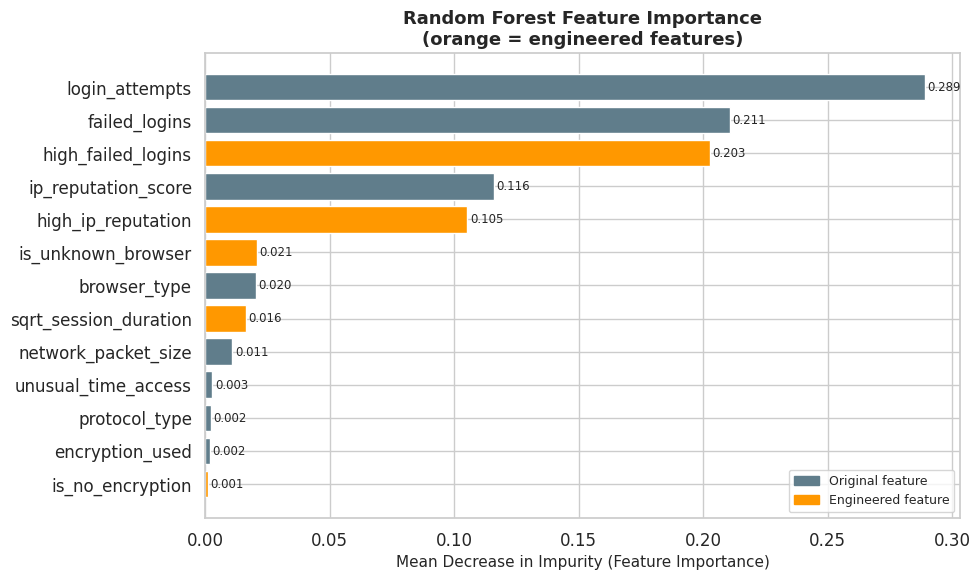

Feature importance ranking:
login_attempts           0.288940
failed_logins            0.210733
high_failed_logins       0.202740
ip_reputation_score      0.115999
high_ip_reputation       0.105341
is_unknown_browser       0.020749
browser_type             0.020495
sqrt_session_duration    0.016324
network_packet_size      0.010881
unusual_time_access      0.002870
protocol_type            0.002134
encryption_used          0.001767
is_no_encryption         0.001026


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df_model = df_fe.copy()
for col in CAT_COLS:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

FEATURES = ['network_packet_size','login_attempts','sqrt_session_duration',
            'ip_reputation_score','failed_logins','unusual_time_access',
            'protocol_type','encryption_used','browser_type',
            'high_failed_logins','high_ip_reputation','is_unknown_browser','is_no_encryption']

X = df_model[FEATURES]
y = df_model['attack_detected']

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
colors = [C['accent'] if '_' in f and f in ['high_failed_logins','high_ip_reputation',
          'is_unknown_browser','is_no_encryption','sqrt_session_duration']
          else C['neutral'] for f in importances.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)', fontsize=11)
ax.set_title('Random Forest Feature Importance\n(orange = engineered features)',
             fontsize=13, fontweight='bold')

handles = [mpatches.Patch(color=C['neutral'], label='Original feature'),
           mpatches.Patch(color=C['accent'],  label='Engineered feature')]
ax.legend(handles=handles, fontsize=9)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature importance ranking:')
print(importances.sort_values(ascending=False).to_string())


**Conclusions:**
- The RF confirms the EDA hierarchy: `high_failed_logins`, `failed_logins`, and `high_ip_reputation` dominate.
- **Engineered features add real lift** — `high_failed_logins` outranks the raw `failed_logins` in impurity reduction, justifying the feature engineering step.
- `unusual_time_access`, `is_no_encryption`, and `protocol_type` contribute the least — candidates for **optional exclusion** in a lean pipeline configuration.


<a id="11"></a>
## 11. Encoding & Scaling Decisions
**Purpose:** Specify exactly how each feature will be treated in the ML pipeline. This section acts as the **contract between EDA and Task 2**.

### Feature Treatment Table

| Feature | Action | Encoding / Transform | Scaling | Rationale |
|---|---|---|---|---|
| `session_id` | **Drop** | — | — | Unique identifier, no predictive value |
| `network_packet_size` | Keep | None | RobustScaler | Near-uniform; Robust handles modest outliers |
| `protocol_type` | Keep | One-Hot Encode (drop first) | — | 3 nominal categories; no natural order |
| `login_attempts` | Keep | None | RobustScaler | Integer count; mild right skew; outliers present |
| `session_duration` | **Transform** | `sqrt(session_duration)` → `sqrt_session_duration` | StandardScaler | Skewness +2.08 → +0.84 after sqrt |
| `encryption_used` | Keep | One-Hot Encode (drop first) | — | 3 nominal categories incl. 'None' |
| `ip_reputation_score` | Keep | None | StandardScaler | Near-uniform 0–1; already bounded |
| `failed_logins` | Keep | None | RobustScaler | Integer; upper values (≥3) are deterministic |
| `browser_type` | Keep | One-Hot Encode (drop first) | — | 5 nominal categories |
| `unusual_time_access` | Keep | Already binary (0/1) | — | No transform needed |
| `high_failed_logins` * | Add | Binary (0/1) | — | `failed_logins >= 3` → 100% attack |
| `high_ip_reputation` * | Add | Binary (0/1) | — | `ip_reputation_score > 0.60` → 100% attack |
| `is_unknown_browser` * | Add | Binary (0/1) | — | Unknown browser → 73% attack rate |
| `is_no_encryption` * | Add | Binary (0/1) | — | No encryption → marginal signal |

> '*' = Engineered feature  
> **Scaler choice note:** `RobustScaler` (median/IQR-based) is preferred for features with confirmed outliers. `StandardScaler` is used for already-bounded continuous features. Tree-based models (RF, XGBoost, DT) do not require scaling — it is applied only for LR, SVM, and KNN.


In [24]:
# Demonstrate the full preprocessed feature set shape
from sklearn.preprocessing import RobustScaler, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_robust = ['network_packet_size','login_attempts','failed_logins']
numeric_std    = ['ip_reputation_score','sqrt_session_duration']
binary_pass    = ['unusual_time_access','high_failed_logins','high_ip_reputation',
                  'is_unknown_browser','is_no_encryption']
categorical    = ['protocol_type','encryption_used','browser_type']

preprocessor = ColumnTransformer(transformers=[
    ('robust',  RobustScaler(),                         numeric_robust),
    ('std',     StandardScaler(),                       numeric_std),
    ('passthru', 'passthrough',                         binary_pass),
    ('ohe',     OneHotEncoder(drop='first', sparse_output=False), categorical),
], remainder='drop')

# Build feature matrix
df_pipe = df_fe.copy()
df_pipe['sqrt_session_duration'] = np.sqrt(df_pipe['session_duration'])
X_demo = df_pipe[numeric_robust + numeric_std + binary_pass + categorical]
X_transformed = preprocessor.fit_transform(X_demo)

print(f'Input feature count:  {X_demo.shape[1]}')
print(f'Output feature count: {X_transformed.shape[1]}  (after OHE expansion)')
print(f'Shape for modelling:  {X_transformed.shape}')


Input feature count:  13
Output feature count: 18  (after OHE expansion)
Shape for modelling:  (9537, 18)


<a id="12"></a>
## 12. Key Findings & Implications

In [25]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    EDA SUMMARY — MALICIOUS TRAFFIC                         ║
╠════════════════════════════╦═══════════════════════════════════════════════╣
║ Dataset                    ║ 9,537 sessions | 10 raw features | 1 target   ║
║ Class balance              ║ 55.3% benign | 44.7% malicious (ratio 1.24:1) ║
║ Missing values             ║ None (encryption='None' is a valid category)  ║
╠════════════════════════════╬═══════════════════════════════════════════════╣
║ DETERMINISTIC RULES        ║                                               ║
║  failed_logins ≥ 3         ║ 100% malicious  (1,584 sessions / 16.6%)      ║
║  ip_reputation_score > 0.6 ║ 100% malicious  (all benign sessions ≤ 0.60) ║
╠════════════════════════════╬═══════════════════════════════════════════════╣
║ TOP PREDICTORS (RF imp.)   ║ Pearson r with attack_detected                ║
║  1. high_failed_logins     ║ r ≈ 0.56 (engineered)                        ║
║  2. failed_logins          ║ r ≈ 0.36                                      ║
║  3. high_ip_reputation     ║ r ≈ 0.47 (engineered)                        ║
║  4. ip_reputation_score    ║ r ≈ 0.21                                      ║
║  5. login_attempts         ║ r ≈ 0.28                                      ║
╠════════════════════════════╬═══════════════════════════════════════════════╣
║ WEAK PREDICTORS            ║ Marginal / consider exclusion                 ║
║  unusual_time_access       ║ r ≈ 0.009 — near zero                        ║
║  network_packet_size       ║ r ≈ -0.007 — noise                           ║
║  protocol_type             ║ attack rate ~41–45% across all protocols      ║
╠════════════════════════════╬═══════════════════════════════════════════════╣
║ DATA ANOMALY               ║ failed_logins > login_attempts possible       ║
║                            ║ Do NOT engineer failed_login_ratio             ║
╠════════════════════════════╬═══════════════════════════════════════════════╣
║ TRANSFORMS                 ║ sqrt(session_duration) — skew +2.08 → +0.84  ║
╚════════════════════════════╩═══════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════════════════╗
║                    EDA SUMMARY — MALICIOUS TRAFFIC                         ║
╠════════════════════════════╦═══════════════════════════════════════════════╣
║ Dataset                    ║ 9,537 sessions | 10 raw features | 1 target   ║
║ Class balance              ║ 55.3% benign | 44.7% malicious (ratio 1.24:1) ║
║ Missing values             ║ None (encryption='None' is a valid category)  ║
╠════════════════════════════╬═══════════════════════════════════════════════╣
║ DETERMINISTIC RULES        ║                                               ║
║  failed_logins ≥ 3         ║ 100% malicious  (1,584 sessions / 16.6%)      ║
║  ip_reputation_score > 0.6 ║ 100% malicious  (all benign sessions ≤ 0.60) ║
╠════════════════════════════╬═══════════════════════════════════════════════╣
║ TOP PREDICTORS (RF imp.)   ║ Pearson r with attack_detected                ║
║  1. high_failed_logins     ║ r ≈ 0.56 (engineere

### SOC Policy Recommendations

| Priority | Rule | Basis |
|---|---|---|
| 🔴 **BLOCK** | `failed_logins ≥ 3` | 100% attack rate; 1,584 sessions affected |
| 🔴 **BLOCK** | `ip_reputation_score > 0.60` | 100% attack rate above this threshold |
| 🟠 **ALERT** | `browser_type = Unknown` | 73% attack rate; likely bot/script traffic |
| 🟡 **MONITOR** | `login_attempts ≥ 7` | Elevated attack rate; combine with IP score |
| 🔵 **POLICY** | `encryption_used = None` | Security gap; enforce encryption at gateway |

### ML Pipeline Directives from EDA

1. **Drop `session_id`** — identifier only
2. **Apply `sqrt` to `session_duration`** before scaling
3. **Add 4 engineered binary features** (`high_failed_logins`, `high_ip_reputation`, `is_unknown_browser`, `is_no_encryption`)
4. **One-hot encode** all three categorical features (drop first)
5. **Use `RobustScaler`** for `network_packet_size`, `login_attempts`, `failed_logins`
6. **Use stratified train/test split** (mild imbalance; 80/20)
7. **Evaluate with F1, ROC-AUC, Precision, Recall** — not accuracy alone
8. **Consider removing** `unusual_time_access` and `protocol_type` in lean configurations
